In [1]:
from pathlib import Path
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from testgen.analysis_utils import *

In [2]:
df = pd.read_excel("data/sensor_requirements.xlsx")

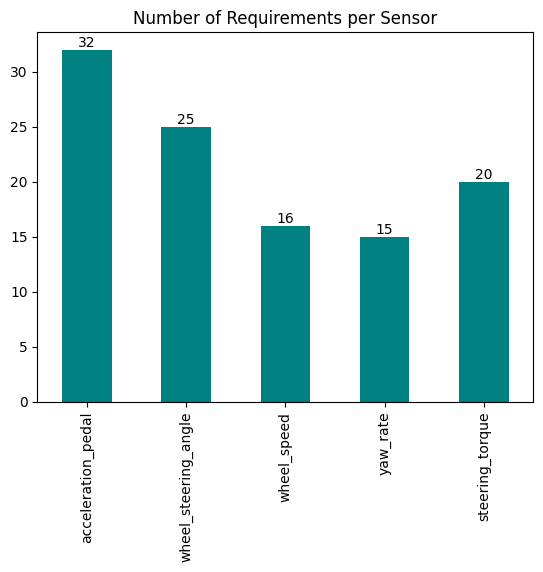

In [3]:
ax = (
    df.drop(columns="requirement")
    .sum()
    .plot.bar(
        title="Number of Requirements per Sensor",
        color="teal",
    )
)

_ = ax.bar_label(ax.containers[0])

In [4]:
labels = get_sensors_labels()
labels

{'acceleration_pedal': 'Acc',
 'wheel_steering_angle': 'WSA',
 'wheel_speed': 'WS',
 'yaw_rate': 'YR',
 'steering_torque': 'ST'}

In [5]:
# read results file
base_path = Path().cwd()
results_path = base_path / "results"

In [6]:
available_results, results_single = get_best_results(
    results_path, "sensor_single*.json"
)
# results_single = pd.DataFrame.from_dict(
#     results_single, orient="index", columns=["n", "acc"]
# )
# results_single.index = results_single.index.str.split("_").str[0]
# results_single.index.name = "model"

In [7]:
stats_df, responses_df, mismatch_stats_df = result_to_df(available_results)

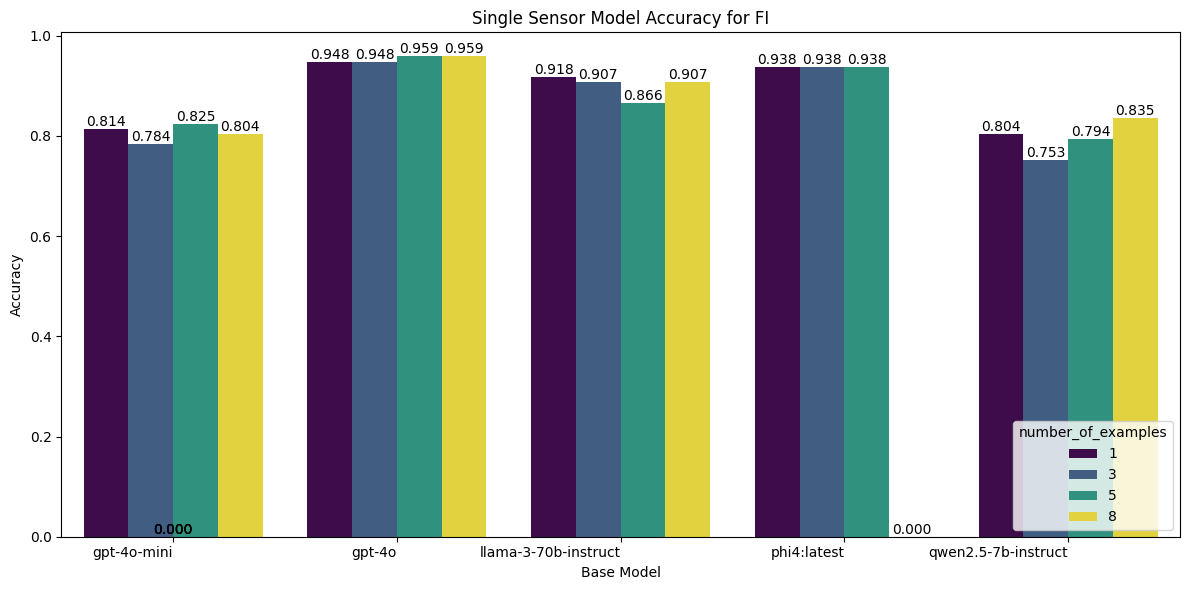

In [8]:
# Create the grouped bar plot using Seaborn
plt.figure(figsize=(12, 6))  # Adjust figure size for better readability
ax = sns.barplot(
    x="model", y="accuracy", hue="number_of_examples", data=stats_df, palette="viridis"
)

# Add data labels
for p in ax.patches:
    ax.annotate(
        format(p.get_height(), ".3f"),
        (p.get_x() + p.get_width() / 2.0, p.get_height()),
        ha="center",
        va="center",
        xytext=(0, 5),
        textcoords="offset points",
        fontsize=10,
    )

# Add title and labels
plt.title("Single Sensor Model Accuracy for FI")
plt.xlabel("Base Model")
plt.ylabel("Accuracy")

# Rotate x-axis labels for better readability if needed
plt.xticks(rotation=0, ha="right")

# Display the plot
plt.tight_layout()  # Adjust layout to prevent labels from overlapping
plt.show()

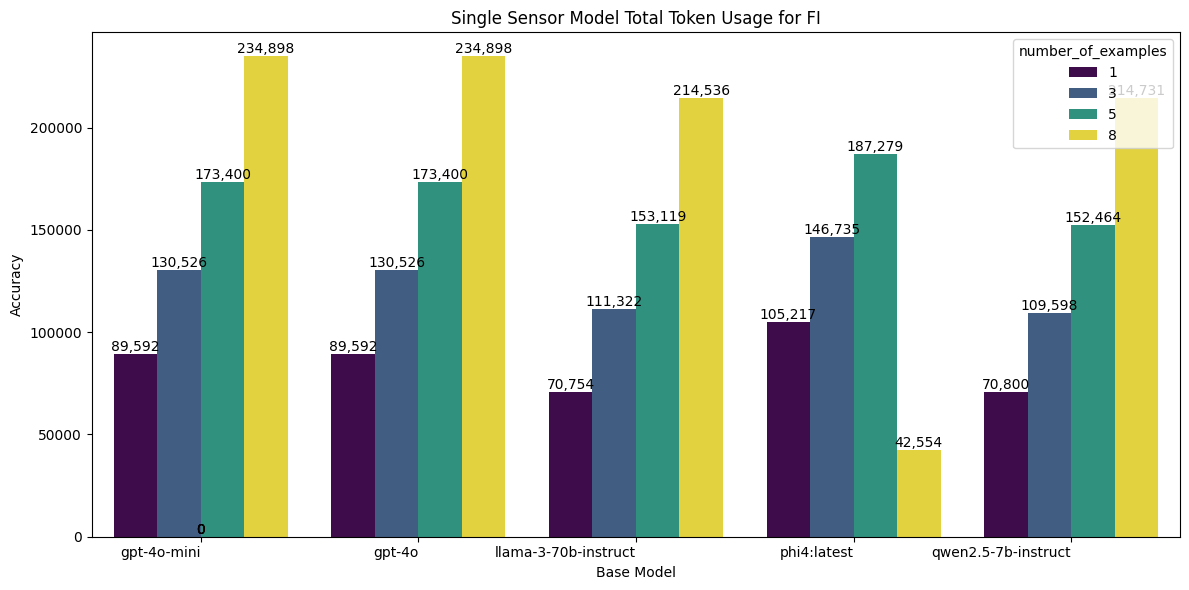

In [9]:
# Create the grouped bar plot using Seaborn
plt.figure(figsize=(12, 6))  # Adjust figure size for better readability
ax = sns.barplot(
    x="model",
    y="total_tokens",
    hue="number_of_examples",
    data=stats_df,
    palette="viridis",
)

# Add data labels
for p in ax.patches:
    ax.annotate(
        format(p.get_height(), ",.0f"),
        (p.get_x() + p.get_width() / 2.0, p.get_height()),
        ha="center",
        va="center",
        xytext=(0, 5),
        textcoords="offset points",
        fontsize=10,
    )

# Add title and labels
plt.title("Single Sensor Model Total Token Usage for FI")
plt.xlabel("Base Model")
plt.ylabel("Accuracy")

# Rotate x-axis labels for better readability if needed
plt.xticks(rotation=0, ha="right")

# Display the plot
plt.tight_layout()  # Adjust layout to prevent labels from overlapping
plt.show()

In [10]:
def replace_and_join(values, labels):
    return " & ".join([labels.get(value) for value in values])


responses_df["pred_target_sensor_str"] = responses_df["pred_target_sensor"].apply(
    lambda x: replace_and_join(x, labels)
)
responses_df["true_target_sensor_str"] = responses_df["true_target_sensor"].apply(
    lambda x: replace_and_join(x, labels)
)

In [11]:
scores_df = calc_scores(responses_df)

scores_df

,model,number_of_examples,accuracy,precision,recall,f1
sensor,,,,,,
All,gpt-4o-mini,1,0.81,0.83,0.98,0.89
Acc,gpt-4o-mini,1,1.00,1.00,1.00,1.00
Acc & WSA,gpt-4o-mini,1,0.92,1.00,0.92,0.96
ST,gpt-4o-mini,1,1.00,1.00,1.00,1.00
WS,gpt-4o-mini,1,1.00,1.00,1.00,1.00
...,...,...,...,...,...,...
Acc & WSA,qwen2.5-7b-instruct,8,0.88,1.00,0.88,0.93
ST,qwen2.5-7b-instruct,8,1.00,1.00,1.00,1.00
WS,qwen2.5-7b-instruct,8,1.00,1.00,1.00,1.00
